In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np

# ================= CONFIG =================
SELECTED_CLASSES = ['frog']  # Выбираем 1 класс для GAN
BATCH_SIZE = 64
NUM_WORKERS = 2
IMG_SIZE = 32
# ==========================================

# 1. Нормализация (стандартные значения для CIFAR-10)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# 2. Аугментации (только для train!)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

# 3. Загрузка и фильтрация по классам
print("Загрузка CIFAR-10...")
raw_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
raw_val   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

class_indices = [raw_train.class_to_idx[cls] for cls in SELECTED_CLASSES]

train_mask = [i for i, t in enumerate(raw_train.targets) if t in class_indices]
val_mask   = [i for i, t in enumerate(raw_val.targets) if t in class_indices]

train_set = Subset(raw_train, train_mask)
val_set   = Subset(raw_val, val_mask)

print(f"Готово: {len(train_set)} train | {len(val_set)} val изображений.")
print(f"Классы: {SELECTED_CLASSES}")

# 4. Создание DataLoader'ов
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, drop_last=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, drop_last=False)

print("\nDataLoader успешно создан.")

Загрузка CIFAR-10...
Готово: 5000 train | 1000 val изображений.
Классы: ['frog']

DataLoader успешно создан.


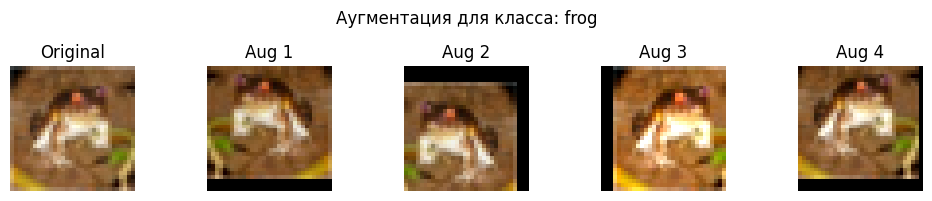

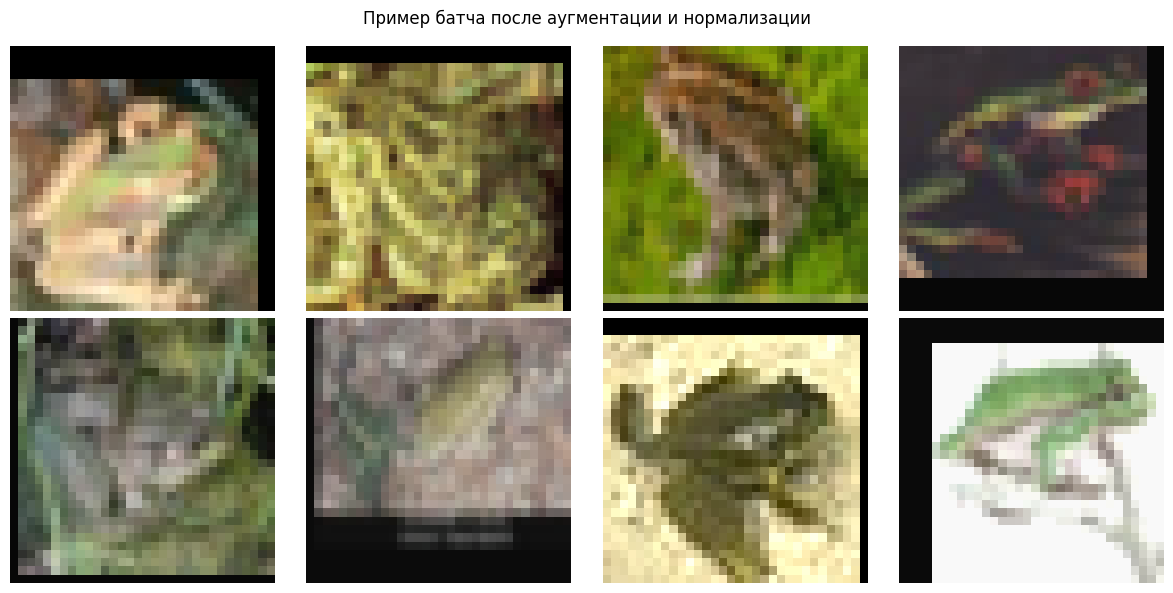

In [2]:
def denormalize(tensor):
    """Обратное преобразование: [-1,1] или N(0,1) -> [0, 1]"""
    return tensor * torch.tensor(CIFAR_STD).view(3, 1, 1) + torch.tensor(CIFAR_MEAN).view(3, 1, 1)

def visualize_augmentation_effect():
    from PIL import Image
    idx = train_mask[0]
    raw_img_np = raw_train.data[idx]  
    raw_pil = Image.fromarray(raw_img_np)

    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    axes[0].imshow(raw_pil)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    for i in range(4):
        aug_tensor = train_transform(raw_pil)  # Применяем аугментацию
        denorm_img = denormalize(aug_tensor).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[i+1].imshow(denorm_img)
        axes[i+1].set_title(f"Aug {i+1}")
        axes[i+1].axis('off')
        
    plt.suptitle(f"Аугментация для класса: {SELECTED_CLASSES[0]}")
    plt.tight_layout()
    plt.show()

def visualize_train_batch():
    images, _ = next(iter(train_loader))
    images = denormalize(images).clamp(0, 1)
    
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.ravel()
    for i in range(8):
        axes[i].imshow(images[i].permute(1, 2, 0).numpy())
        axes[i].axis('off')
    plt.suptitle("Пример батча после аугментации и нормализации")
    plt.tight_layout()
    plt.show()

# Запуск визуализаций
visualize_augmentation_effect()
visualize_train_batch()

In [3]:
import torch.nn as nn
import torch.nn.functional as F

# Константы
LATENT_DIM = 100
IMG_CHANNELS = 3
IMG_SIZE = 32

# Универсальная инициализация
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# === Архитектура 1: MLP Baseline ===
class Generator_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(LATENT_DIM, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, IMG_CHANNELS * IMG_SIZE * IMG_SIZE),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(img.size(0), IMG_CHANNELS, IMG_SIZE, IMG_SIZE)

class Discriminator_MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(IMG_CHANNELS * IMG_SIZE * IMG_SIZE, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        return self.model(x_flat)

# === Архитектура 2: DCGAN Base ===
class Generator_DCGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, IMG_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, LATENT_DIM, 1, 1)
        return self.model(z)

class Discriminator_DCGAN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.model(x)
        return out.view(out.size(0), -1)

# === Архитектура 3: DCGAN + Dropout ===
class Generator_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 256, 4, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Dropout2d(0.3),
            nn.ConvTranspose2d(64, IMG_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, LATENT_DIM, 1, 1)
        return self.model(z)

class Discriminator_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        out = self.model(x)
        return out.view(out.size(0), -1)

# === Архитектура 4: ResBlock (без Attention) ===
class ResBlockUp(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.shortcut = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        h = F.relu(self.bn1(self.conv1(x)))
        h = self.bn2(self.conv2(h))
        h = self.upsample(h)
        x_up = self.upsample(self.shortcut(x))
        return h + x_up

class Generator_ResBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial = nn.Linear(LATENT_DIM, 256 * 4 * 4)
        self.blocks = nn.Sequential(
            ResBlockUp(256, 128),
            ResBlockUp(128, 64),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.Conv2d(64, IMG_CHANNELS, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = F.relu(self.initial(z)).view(-1, 256, 4, 4)
        return self.blocks(x)

class Discriminator_ResBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x).view(x.size(0), -1)

# === Архитектура 5: Упрощённый DCGAN (меньше параметров) ===
class Generator_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 128, 4, 1, 0, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, IMG_CHANNELS, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, LATENT_DIM, 1, 1)
        return self.model(z)

class Discriminator_Simple(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(x.size(0), -1)

Using device: cuda
Starting Training Loop...
[0/20][0/78] Loss_D: 1.3876 Loss_G: 2.1777 D(x): 0.4065 D(G(z)): 0.3181 / 0.1339


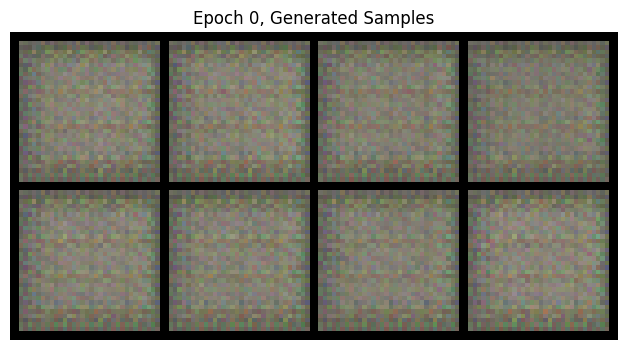

[1/20][0/78] Loss_D: 0.0644 Loss_G: 5.4256 D(x): 0.9681 D(G(z)): 0.0301 / 0.0052
[2/20][0/78] Loss_D: 0.6318 Loss_G: 6.4768 D(x): 0.8598 D(G(z)): 0.3367 / 0.0021
[3/20][0/78] Loss_D: 0.1663 Loss_G: 4.5230 D(x): 0.9205 D(G(z)): 0.0668 / 0.0161
[4/20][0/78] Loss_D: 0.1614 Loss_G: 4.6243 D(x): 0.9395 D(G(z)): 0.0829 / 0.0198
[5/20][0/78] Loss_D: 0.2617 Loss_G: 4.3159 D(x): 0.8590 D(G(z)): 0.0676 / 0.0174


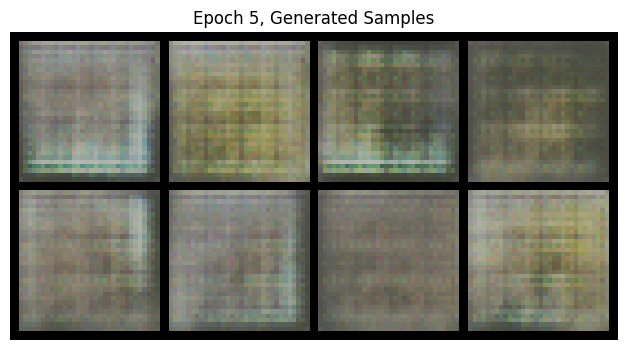

[6/20][0/78] Loss_D: 0.2921 Loss_G: 4.0454 D(x): 0.8787 D(G(z)): 0.0981 / 0.0383
[7/20][0/78] Loss_D: 0.8283 Loss_G: 6.2222 D(x): 0.9855 D(G(z)): 0.4674 / 0.0114
[8/20][0/78] Loss_D: 0.1687 Loss_G: 4.2956 D(x): 0.8925 D(G(z)): 0.0242 / 0.0198
[9/20][0/78] Loss_D: 0.2218 Loss_G: 5.0662 D(x): 0.9156 D(G(z)): 0.1076 / 0.0112
[10/20][0/78] Loss_D: 0.1084 Loss_G: 5.4530 D(x): 0.9568 D(G(z)): 0.0548 / 0.0084


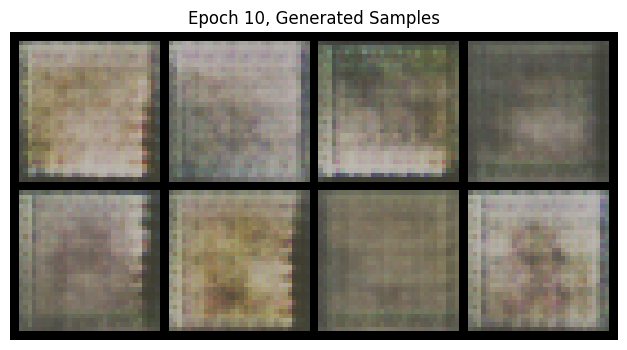

[11/20][0/78] Loss_D: 0.1920 Loss_G: 6.3269 D(x): 0.8548 D(G(z)): 0.0019 / 0.0035
[12/20][0/78] Loss_D: 0.1778 Loss_G: 3.7461 D(x): 0.8678 D(G(z)): 0.0144 / 0.0427
[13/20][0/78] Loss_D: 0.0969 Loss_G: 5.8317 D(x): 0.9742 D(G(z)): 0.0642 / 0.0048
[14/20][0/78] Loss_D: 0.2040 Loss_G: 7.4554 D(x): 0.8862 D(G(z)): 0.0052 / 0.0015
[15/20][0/78] Loss_D: 0.0506 Loss_G: 5.0956 D(x): 0.9762 D(G(z)): 0.0236 / 0.0105


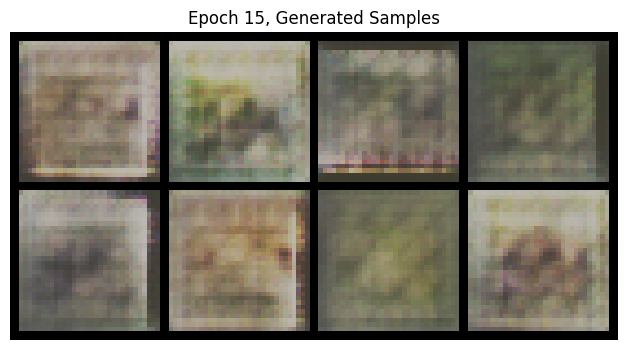

[16/20][0/78] Loss_D: 0.0856 Loss_G: 4.8287 D(x): 0.9775 D(G(z)): 0.0582 / 0.0158
[17/20][0/78] Loss_D: 0.1107 Loss_G: 5.3993 D(x): 0.9818 D(G(z)): 0.0786 / 0.0085
[18/20][0/78] Loss_D: 0.1161 Loss_G: 3.8054 D(x): 0.9471 D(G(z)): 0.0569 / 0.0328
[19/20][0/78] Loss_D: 0.0645 Loss_G: 6.2312 D(x): 0.9768 D(G(z)): 0.0381 / 0.0065


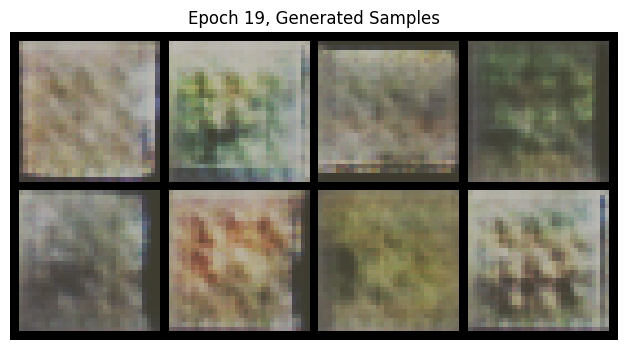

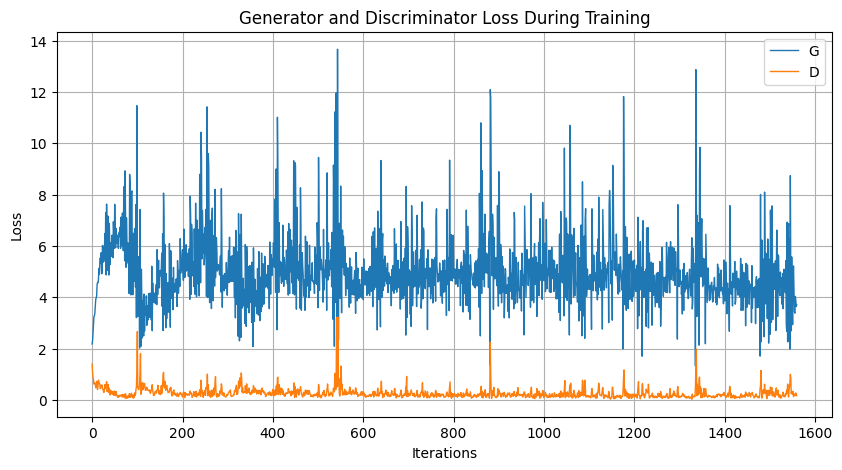

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Выбираем архитектуру (например, DCGAN)
netG = Generator_DCGAN().to(device)
netD = Discriminator_DCGAN().to(device)

# Инициализация весов
netG.apply(weights_init)
netD.apply(weights_init)

# Оптимизаторы
import torch.optim as optim
optimizerG = optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerD = optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5, 0.999))

# Функция потерь
criterion = nn.BCELoss()

# Параметры
num_epochs = 20
fixed_noise = torch.randn(64, LATENT_DIM, device=device)
real_label = 1.0
fake_label = 0.0

# Логирование
G_losses = []
D_losses = []

def save_images(fake_images, epoch):
    fake_images = denormalize(fake_images).clamp(0, 1)
    grid = torchvision.utils.make_grid(fake_images[:8], nrow=4, normalize=False)
    plt.figure(figsize=(8, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(f'Epoch {epoch}, Generated Samples')
    plt.axis('off')
    plt.show()

print("Starting Training Loop...")

for epoch in range(num_epochs):
    for i, (data, _) in enumerate(train_loader):
        ############################
        # (1) Обновляем D
        ###########################
        netD.zero_grad()
        real_cpu = data.to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        
        output = netD(real_cpu).squeeze()
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, LATENT_DIM, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).squeeze()
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        ############################
        # (2) Обновляем G
        ###########################
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).squeeze()
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 100 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(train_loader)}] '
                  f'Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} '
                  f'D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}')

    if (epoch % 5 == 0) or (epoch == num_epochs - 1):
        with torch.no_grad():
            fake = netG(fixed_noise).detach().cpu()
            save_images(fake, epoch)

# Визуализация лоссов
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G", linewidth=1)
plt.plot(D_losses, label="D", linewidth=1)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

In [5]:
architectures = {
    "MLP": (Generator_MLP, Discriminator_MLP),
    "DCGAN": (Generator_DCGAN, Discriminator_DCGAN),
    "DCGAN+Drop": (Generator_Dropout, Discriminator_Dropout),
    #"ResBlock": (Generator_ResBlock, Discriminator_ResBlock),
    "Simple": (Generator_Simple, Discriminator_Simple)
}

import pandas as pd

results = {}
criterion = nn.BCELoss()

for name, (GenClass, DiscClass) in architectures.items():
    print(f"\n🔄 Обучение архитектуры: {name}")

    # Инициализация модели
    netG = GenClass().to(device).apply(weights_init)
    netD = DiscClass().to(device).apply(weights_init)

    optimizerG = optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optimizerD = optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5, 0.999))

    # Обучение (уменьшим эпохи для скорости)
    epochs = 5
    G_losses_run = []
    D_losses_run = []

    for epoch in range(epochs):
        for i, (data, _) in enumerate(train_loader):
            # Обновление D
            netD.zero_grad()
            real_cpu = data.to(device)
            b_size = real_cpu.size(0)
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

            output = netD(real_cpu).squeeze()
            errD_real = criterion(output, label)
            errD_real.backward()

            noise = torch.randn(b_size, LATENT_DIM, device=device)
            fake = netG(noise)
            label.fill_(fake_label)
            output = netD(fake.detach()).squeeze()
            errD_fake = criterion(output, label)
            errD_fake.backward()
            errD = errD_real + errD_fake
            optimizerD.step()

            # Обновление G
            netG.zero_grad()
            label.fill_(real_label)
            output = netD(fake).squeeze()
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()

            G_losses_run.append(errG.item())
            D_losses_run.append(errD.item())

    # Оценка: средняя уверенность D на сгенерированных изображениях
    with torch.no_grad():
        test_noise = torch.randn(200, LATENT_DIM, device=device)
        fake_images = netG(test_noise)
        d_outputs = netD(fake_images).squeeze()
        avg_confidence = d_outputs.mean().item()
        std_confidence = d_outputs.std().item()

    results[name] = {
        'avg_D_conf': avg_confidence,
        'std_D_conf': std_confidence,
        'final_G_loss': G_losses_run[-1],
        'final_D_loss': D_losses_run[-1],
        'total_params_G': sum(p.numel() for p in netG.parameters()),
        'total_params_D': sum(p.numel() for p in netD.parameters())
    }
    print(f"✅ {name}: Avg D(G(z)) = {avg_confidence:.3f}")

# Вывод таблицы
df_results = pd.DataFrame(results).T
df_results.index.name = 'Architecture'
df_results = df_results.round(4)

print("\n📊 Сравнение архитектур:")
display(df_results)


🔄 Обучение архитектуры: MLP
✅ MLP: Avg D(G(z)) = 0.380

🔄 Обучение архитектуры: DCGAN
✅ DCGAN: Avg D(G(z)) = 0.144

🔄 Обучение архитектуры: DCGAN+Drop
✅ DCGAN+Drop: Avg D(G(z)) = 0.036

🔄 Обучение архитектуры: Simple


RuntimeError: Calculated padded input size per channel: (2 x 2). Kernel size: (4 x 4). Kernel size can't be greater than actual input size

In [6]:
class Generator_Simple_Fixed(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(LATENT_DIM, 128, 4, 1, 0, bias=False),  # (B, 100, 1, 1) -> (B, 128, 4, 4)
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),         # (B, 128, 4, 4) -> (B, 64, 8, 8)
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),          # (B, 64, 8, 8) -> (B, 32, 16, 16)
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            nn.ConvTranspose2d(32, IMG_CHANNELS, 4, 2, 1, bias=False), # (B, 32, 16, 16) -> (B, 3, 32, 32) ✅
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(-1, LATENT_DIM, 1, 1)
        return self.model(z)

In [8]:
architectures_final = {
    "MLP": (Generator_MLP, Discriminator_MLP),
    "DCGAN": (Generator_DCGAN, Discriminator_DCGAN),
    "DCGAN+Drop": (Generator_Dropout, Discriminator_Dropout),
    #"ResBlock": (Generator_ResBlock_Fixed, Discriminator_ResBlock_Fixed),
    "Simple": (Generator_Simple_Fixed, Discriminator_Simple)  # Подменяем Generator
}

In [9]:
import pandas as pd
import torch.optim as optim

results = {}
criterion = nn.BCELoss()

for name, (GenClass, DiscClass) in architectures_final.items():
    print(f"\n🔄 Обучение архитектуры: {name}")

    # Инициализация модели
    netG = GenClass().to(device).apply(weights_init)
    netD = DiscClass().to(device).apply(weights_init)

    optimizerG = optim.Adam(netG.parameters(), lr=2e-4, betas=(0.5, 0.999))
    optimizerD = optim.Adam(netD.parameters(), lr=2e-4, betas=(0.5, 0.999))

    # Обучение (уменьшим эпохи для скорости)
    epochs = 3  # Ещё меньше эпох для CPU
    G_losses_run = []
    D_losses_run = []

    for epoch in range(epochs):
        for i, (data, _) in enumerate(train_loader):
            # Обновление D
            netD.zero_grad()
            real_cpu = data.to(device)
            b_size = real_cpu.size(0)
            label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

            output = netD(real_cpu).squeeze()
            errD_real = criterion(output, label)
            errD_real.backward()

            noise = torch.randn(b_size, LATENT_DIM, device=device)
            fake = netG(noise)
            label.fill_(fake_label)
            output = netD(fake.detach()).squeeze()
            errD_fake = criterion(output, label)
            errD_fake.backward()
            errD = errD_real + errD_fake
            optimizerD.step()

            # Обновление G
            netG.zero_grad()
            label.fill_(real_label)
            output = netD(fake).squeeze()
            errG = criterion(output, label)
            errG.backward()
            optimizerG.step()

            G_losses_run.append(errG.item())
            D_losses_run.append(errD.item())

    # Оценка: средняя уверенность D на сгенерированных изображениях
    with torch.no_grad():
        test_noise = torch.randn(200, LATENT_DIM, device=device)
        fake_images = netG(test_noise)
        d_outputs = netD(fake_images).squeeze()
        avg_confidence = d_outputs.mean().item()
        std_confidence = d_outputs.std().item()

    results[name] = {
        'avg_D_conf': avg_confidence,
        'std_D_conf': std_confidence,
        'final_G_loss': G_losses_run[-1],
        'final_D_loss': D_losses_run[-1],
        'total_params_G': sum(p.numel() for p in netG.parameters()),
        'total_params_D': sum(p.numel() for p in netD.parameters())
    }
    print(f"✅ {name}: Avg D(G(z)) = {avg_confidence:.3f}")

# Вывод таблицы
df_results = pd.DataFrame(results).T
df_results.index.name = 'Architecture'
df_results = df_results.round(4)

print("\n📊 Сравнение архитектур:")
display(df_results)


🔄 Обучение архитектуры: MLP
✅ MLP: Avg D(G(z)) = 0.498

🔄 Обучение архитектуры: DCGAN
✅ DCGAN: Avg D(G(z)) = 0.035

🔄 Обучение архитектуры: DCGAN+Drop
✅ DCGAN+Drop: Avg D(G(z)) = 0.034

🔄 Обучение архитектуры: Simple
✅ Simple: Avg D(G(z)) = 0.117

📊 Сравнение архитектур:


,avg_D_conf,std_D_conf,final_G_loss,final_D_loss,total_params_G,total_params_D
Architecture,,,,,,
MLP,0.4977,0.1064,1.1973,0.8612,3831552.0,3803137.0
DCGAN,0.0355,0.0273,4.8123,0.0801,1068928.0,663296.0
DCGAN+Drop,0.0343,0.0737,6.3631,0.3387,1068928.0,663296.0
Simple,0.1175,0.1374,6.0088,0.0544,370624.0,663296.0
